In [192]:
import importlib
import pandas as pd
import preprocess_behav2p as preprocess
import analysis_functions as af
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.decomposition import PCA
from scipy.signal import savgol_filter
from scipy import stats
import os
import pickle
from matplotlib.animation import FuncAnimation
from io_utils import save_pickle, load_pickle
import init_vars as iv
import visualize as viz
import scipy
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from scipy.ndimage import gaussian_filter1d

In [ ]:
# RELOAD 
importlib.reload(preprocess)
data_dir = r'Y:\\public\\projects\SaEl_20220201_VIP\\2pdata\subj_record.xlsx'
sheet_name = 'LC_DREADDs'
table = pd.read_excel(data_dir, sheet_name=sheet_name)
comb = {}
neuropil_factor = 0.1
tri_perc = 1
for ani in [0]:
    # Run preprocessing for each animal/session
    ani, pp = preprocess.main(ani, table,sheet_name, neuropil_factor, tri_perc,basesub=1, roitype='suite2p')
    comb[ani] = {
        'n_gratings': pp.n_gratings,
        'unpred_trials': pp.unpred_trials,
        'pred_trials': pp.pred_trials,
        'trial_start_indices': pp.trial_start_indices,
        'grating_indices': pp.grating_indices,
        'dff_Zscore': pp.dff_Zscore,
        'n_planes': pp.n_planes,
        'n_trial': pp.n_trials,
        'aligned_data': pp.aligned_data,
        'reward_indices': pp.reward_indices,
        'activity': pp.activity,
        'TC': pp.TC,
        'position': pp.position,
        'position_tunnel': pp.position_tunnel,
        'speed': pp.speed,
        'trial_type': pp.trial_types,
        'pupil': pp.pupil,
        'lick': pp.lick
    }

data = {}
importlib.reload(iv)
for ani in comb.keys():
    data[ani] ={}
    data[ani]['aligned_data'] = comb[ani]['aligned_data']
    data[ani]['activity'] = comb[ani]['activity']
    data[ani]['unpred_trials'] = comb[ani]['unpred_trials']
    data[ani]['pred_trials'] = comb[ani]['pred_trials']
    data[ani]['dff_Zscore'] = comb[ani]['dff_Zscore']
    data[ani]['trial_start_indices'] = comb[ani]['trial_start_indices']
    data[ani]['type'] = table.iloc[ani][3]
    data[ani]['grating_indices']= comb[ani]['grating_indices']
    data[ani]['reward_indices']= comb[ani]['reward_indices']
    data[ani]['n_gratings'] = comb[ani]['n_gratings']
    data[ani]['n_trial'] = comb[ani]['n_trial']
    if table.iloc[ani][1] == 1:
        data[ani]['position_tunnel'] = comb[ani]['position_tunnel']
        data[ani]['position'] = comb[ani]['position']
        data[ani]['speed'] = comb[ani]['speed']
        data[ani]['lick'] = comb[ani]['lick']
        data[ani]['pupil'] = comb[ani]['pupil']
    else:
        data[ani]['position'] = comb[ani]['aligned_data' ]['Averaged_Position']
        try:
            data[ani]['pupil'] = comb[ani]['aligned_data']['pupil_diameter']
            data[ani] = iv.process_pupil(data[ani])
        except KeyError:
            data[ani]['pupil'] = None

        data[ani]['speed'] = comb[ani]['aligned_data']['Speed_Absolute']
        data[ani] = iv.process_speed(data[ani])

    save_pickle(data[ani], "all_data_red", base_path=table.iloc[ani][2])

No F_red.npy in plane2, skipping.
R2=0.9999999992221519 ---- Slope=1.00002162637484 ---- intercept=0.6907996820664835
Using DLC file: PupilCamera_CameraVideoDLC_resnet50_pupil-setup2-bonsaiJan21shuffle1_500000_filtered.csv
Detected 1 excess frames in the downsampled data. Discarding these frames.
bonsai done


In [193]:
# LOAD DATA
importlib.reload(preprocess)
data_dir = r'Y:\\public\\projects\SaEl_20220201_VIP\\2pdata\subj_record.xlsx'
sheet_name = 'LC_DREADDs'
table = pd.read_excel(data_dir, sheet_name=sheet_name)
data_red = {}
data = {}
neuropil_factor = 0.1
tri_perc = 1
for ani in [0]:
    data_red[ani] = load_pickle('all_data_red',base_path=table.iloc[ani][2])
    data[ani] = load_pickle('all_data',base_path=table.iloc[ani][2])

In [ ]:
# activity data looks weird? --- is the preprocessing correct? --- yes
# looked at the rois. are the rois in suite2p all cells? --- changed the code about iscell in preprocessing to >0.5. --- it's fine to include all rois and use threshold to select sig cells later
# checked grating indices --- looks correct
# but why does the stim evoked response look so weird????? --- ,,, need to select sig_cells 
# find vip cells? how to register by the red channel? --- open imageJ & extract imgJ, need to ask again 
# is the opto correct? make a variable named opto trials that contains 
# what plots? just psth should be good. VIP and non-VIP cells in ctl and opto trials/gratings
# no unpredicted trial
# Use first 10 trials --- before water leak
# No unpred trials

In [236]:
opto = np.where(data[ani]['aligned_data']['Opto'].values == 1) # check opto --- opto at grat 2 and 3 looks correct
opto_frames = set(opto[0])
opto_idx = np.array([i for i, frames in enumerate(data[ani]['grating_indices']['gr_2'])
                     if opto_frames.intersection(frames)])
opto_idx = opto_idx[opto_idx<12] # opto trials before water leak
non_opto_idx_all = np.setdiff1d(np.arange(12),opto_idx)   # non opto trials in the first 15 trials
non_opto_idx = opto_idx[1:]-1    

prestim_frames = slice(10,15)
poststim_frames = slice(23,33)

print('opto trials:', opto_idx)
print('non-opto trials:', non_opto_idx)
print('all non-opto trials:', non_opto_idx_all)

sig_cells={}
sig_cells[ani]={}
for grating in ['gr_1','gr_2','gr_3','gr_4']:
    # sig_cells_opto = af.find_significant_neurons_threshold(data[ani]['activity'][grating], opto_idx, 0.5, prestim_frames, poststim_frames)[0]
    sig_cells_ctl = af.find_significant_neurons_threshold(data[ani]['activity'][grating], non_opto_idx_all, 0.5, prestim_frames, poststim_frames)[0]
    # sig_cells[ani][grating] = np.union1d(sig_cells_opto, sig_cells_ctl)
    sig_cells[ani][grating] = sig_cells_ctl  # here I use all the ctl trials

print('sig_cells:')
for gr in ['gr_1', 'gr_2', 'gr_3', 'gr_4']:
    cells = sig_cells[ani][gr]
    print(f"{gr}: {len(cells):3d} cells  {cells}")

opto trials: [ 0  4  8 10]
non-opto trials: [3 7 9]
all non-opto trials: [ 1  2  3  5  6  7  9 11]
sig_cells:
gr_1:   4 cells  [5, 17, 46, 61]
gr_2:   7 cells  [9, 15, 17, 64, 66, 100, 104]
gr_3:   6 cells  [17, 24, 36, 38, 46, 61]
gr_4:  10 cells  [5, 9, 17, 26, 28, 32, 35, 66, 70, 104]


[Text(11.5, 0, '-1'), Text(19.0, 0, '0'), Text(26.5, 0, '1')]

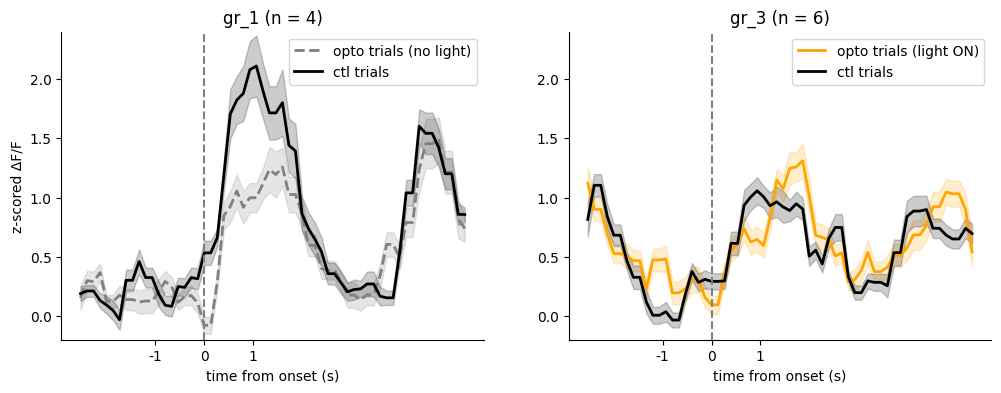

In [287]:
fig,axes = plt.subplots(1,2,figsize=(12,4))

grating = 'gr_1'
viz.plot_shaded_error(axes[0],range(60), np.vstack(data[ani]['activity'][grating][sig_cells[ani][grating]][:,opto_idx]), color='gray', label='opto trials (no light)', alpha=0.2,title=grating,style='dash')
viz.plot_shaded_error(axes[0],range(60), np.vstack(data[ani]['activity'][grating][sig_cells[ani][grating]][:,non_opto_idx]), color='black', label='ctl trials', alpha=0.2,style=None)
axes[0].axvline(19, linestyle='--', color='grey')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].set_title(grating+ f' (n = {str(len(sig_cells[ani][grating]))})')
axes[0].set_ylabel('z-scored ΔF/F')
axes[0].set_xlabel('time from onset (s)')
axes[0].set_ylim([-0.2,2.4])
axes[0].set_xticks([11.5, 19, 26.5])
axes[0].set_xticklabels(['-1', '0', '1'])

grating = 'gr_3'
viz.plot_shaded_error(axes[1],range(60), np.vstack(data[ani]['activity'][grating][sig_cells[ani][grating]][:,opto_idx]), color='orange', label='opto trials (light ON)', alpha=0.2,title=grating,style=None)
viz.plot_shaded_error(axes[1],range(60), np.vstack(data[ani]['activity'][grating][sig_cells[ani][grating]][:,non_opto_idx]), color='black', label='ctl trials', alpha=0.2,style=None)
axes[1].axvline(19, linestyle='--', color='grey')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].set_title(grating+ f' (n = {str(len(sig_cells[ani][grating]))})')
# axes[1].set_ylabel('z-scored ΔF/F')
axes[1].set_xlabel('time from onset (s)')
axes[1].set_ylim([-0.2,2.4])
axes[1].set_xticks([11.5, 19, 26.5])
axes[1].set_xticklabels(['-1', '0', '1'])

[Text(11.5, 0, '-1'), Text(19.0, 0, '0'), Text(26.5, 0, '1')]

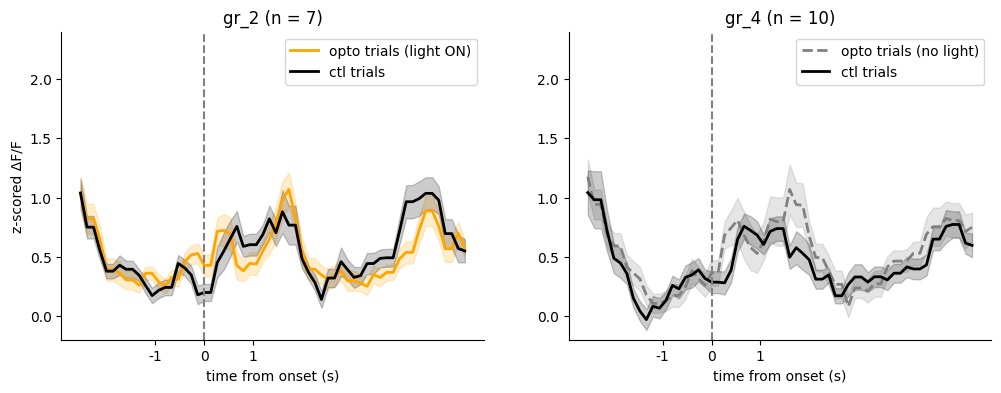

In [289]:
fig,axes = plt.subplots(1,2,figsize=(12,4))

grating = 'gr_2'
viz.plot_shaded_error(axes[0],range(60), np.vstack(data[ani]['activity'][grating][sig_cells[ani][grating]][:,opto_idx]), color='orange', label='opto trials (light ON)', alpha=0.2,title=grating,style=None)
viz.plot_shaded_error(axes[0],range(60), np.vstack(data[ani]['activity'][grating][sig_cells[ani][grating]][:,non_opto_idx]), color='black', label='ctl trials', alpha=0.2,style=None)
axes[0].axvline(19, linestyle='--', color='grey')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].set_title(grating+ f' (n = {str(len(sig_cells[ani][grating]))})')
axes[0].set_ylabel('z-scored ΔF/F')
axes[0].set_xlabel('time from onset (s)')
axes[0].set_ylim([-0.2,2.4])
axes[0].set_xticks([11.5, 19, 26.5])
axes[0].set_xticklabels(['-1', '0', '1'])

grating = 'gr_4'
viz.plot_shaded_error(axes[1],range(60), np.vstack(data[ani]['activity'][grating][sig_cells[ani][grating]][:,opto_idx]), color='gray', label='opto trials (no light)', alpha=0.2,title=grating,style='dash')
viz.plot_shaded_error(axes[1],range(60), np.vstack(data[ani]['activity'][grating][sig_cells[ani][grating]][:,non_opto_idx]), color='black', label='ctl trials', alpha=0.2,style=None)
axes[1].axvline(19, linestyle='--', color='grey')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].set_title(grating+ f' (n = {str(len(sig_cells[ani][grating]))})')
# axes[1].set_ylabel('z-scored ΔF/F')
axes[1].set_ylim([-0.2,2.4])
axes[1].set_xlabel('time from onset (s)')
axes[1].set_xticks([11.5, 19, 26.5])
axes[1].set_xticklabels(['-1', '0', '1'])

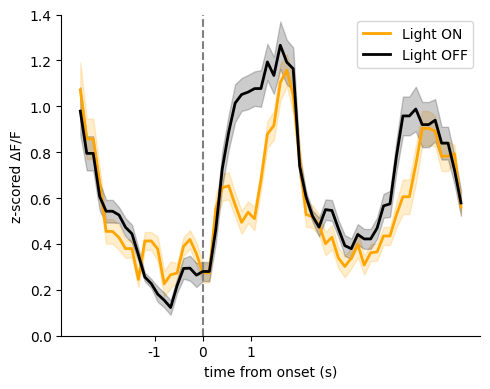

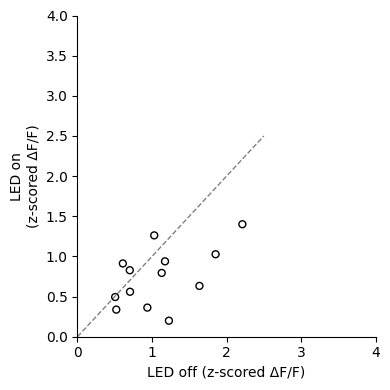

In [316]:
gr_a = 'gr_3'
gr_b = 'gr_2'
opto_color = 'orange'

opto_trace = np.vstack([
    data[ani]['activity'][gr_a][sig_cells[ani][gr_a]][:, opto_idx, :].mean(axis=1),
    data[ani]['activity'][gr_b][sig_cells[ani][gr_b]][:, opto_idx, :].mean(axis=1),
])
ctl_trace = np.vstack([
    data[ani]['activity'][gr_a][sig_cells[ani][gr_a]][:, non_opto_idx_all, :].mean(axis=1),
    data[ani]['activity'][gr_b][sig_cells[ani][gr_b]][:, non_opto_idx_all, :].mean(axis=1),
])

opto_v = opto_trace[:, poststim].mean(axis=1)
ctl_v  = ctl_trace[:, poststim].mean(axis=1)

fig, ax_trace = plt.subplots(1, 1, figsize=(5, 4))

# Trace
viz.plot_shaded_error(ax_trace, range(n_frames), opto_trace, color=opto_color, alpha=0.2, style='none',label='Light ON')
viz.plot_shaded_error(ax_trace, range(n_frames), ctl_trace,  color='black', alpha=0.2, style=None,label='Light OFF')
ax_trace.axvline(19, linestyle='--', color='grey')
ax_trace.set_xticks([11.5, 19, 26.5])
ax_trace.set_xticklabels(['-1', '0', '1'])
ax_trace.set_ylabel('z-scored ΔF/F')
ax_trace.set_xlabel('time from onset (s)')
# ax_trace.set_yticks([])
ax_trace.set_ylim([0,1.4])
ax_trace.spines['top'].set_visible(False)
ax_trace.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

fig, ax_sc = plt.subplots(1, 1, figsize=(4, 4))
# Scatter
ax_sc.scatter(ctl_v, opto_v, facecolor='none', edgecolor='black', s=25)
ax_sc.set_xlim([0,4])
ax_sc.set_ylim([0,4])
ax_sc.plot([0,2.5], [0,2.5], 'k--', lw=1, alpha=0.5)
ax_sc.set_xlim(lims); ax_sc.set_ylim(lims)
ax_sc.set_xlabel('LED off (z-scored ΔF/F)')
ax_sc.set_ylabel('LED on\n(z-scored ΔF/F)')
ax_sc.set_xlim([0,4])
ax_sc.set_ylim([0,4])   
ax_sc.spines['top'].set_visible(False)
ax_sc.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


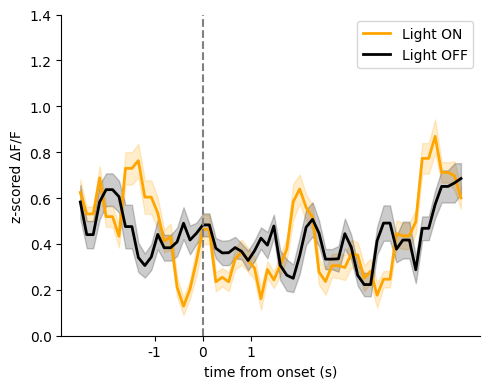

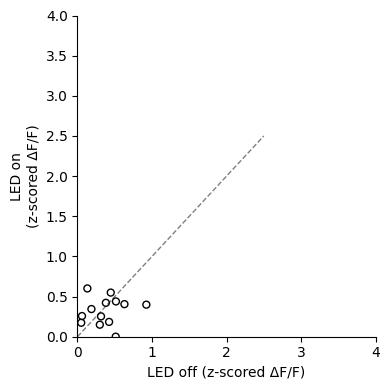

In [325]:
gr_a = 'gr_3'
gr_b = 'gr_2'
opto_color = 'orange'

opto_trace = np.vstack([
    data_red[ani]['activity'][gr_a][:, opto_idx].mean(axis=1),
    data_red[ani]['activity'][gr_b][:, opto_idx].mean(axis=1),
])
ctl_trace = np.vstack([
    data_red[ani]['activity'][gr_a][:, non_opto_idx].mean(axis=1),
    data_red[ani]['activity'][gr_b][:, non_opto_idx].mean(axis=1),
])

opto_v = opto_trace[:, poststim].mean(axis=1)
ctl_v  = ctl_trace[:, poststim].mean(axis=1)

fig, ax_trace = plt.subplots(1, 1, figsize=(5, 4))
# Trace
viz.plot_shaded_error(ax_trace, range(n_frames), opto_trace, color=opto_color, alpha=0.2, style='none',label='Light ON')
viz.plot_shaded_error(ax_trace, range(n_frames), ctl_trace,  color='black', alpha=0.2, style=None,label='Light OFF')
ax_trace.axvline(19, linestyle='--', color='grey')
ax_trace.set_xticks([11.5, 19, 26.5])
ax_trace.set_xticklabels(['-1', '0', '1'])
ax_trace.set_ylabel('z-scored ΔF/F')
ax_trace.set_xlabel('time from onset (s)')
# ax_trace.set_yticks([])
ax_trace.set_ylim([0,1.4])
ax_trace.spines['top'].set_visible(False)
ax_trace.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

fig, ax_sc = plt.subplots(1, 1, figsize=(4, 4))
# Scatter
ax_sc.scatter(ctl_v, opto_v, facecolor='none', edgecolor='black', s=25)
ax_sc.set_xlim([0,4])
ax_sc.set_ylim([0,4])
ax_sc.plot([0,2.5], [0,2.5], 'k--', lw=1, alpha=0.5)
ax_sc.set_xlim(lims); ax_sc.set_ylim(lims)
ax_sc.set_xlabel('LED off (z-scored ΔF/F)')
ax_sc.set_ylabel('LED on\n(z-scored ΔF/F)')
ax_sc.set_xlim([0,4])
ax_sc.set_ylim([0,4])   
ax_sc.spines['top'].set_visible(False)
ax_sc.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


[Text(12.5, 0, '-1'), Text(20.0, 0, '0'), Text(27.5, 0, '1')]

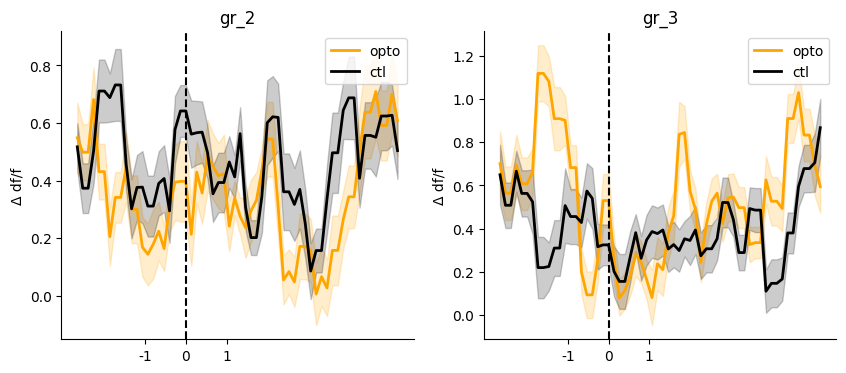

In [329]:
fig,axes = plt.subplots(1,2,figsize=(10,4))

grating = 'gr_2'
viz.plot_shaded_error(axes[0],range(60), np.vstack(data_red[ani]['activity'][grating][:,opto_idx]), color='orange', label='opto', alpha=0.2,title=grating,style=None)
viz.plot_shaded_error(axes[0],range(60), np.vstack(data_red[ani]['activity'][grating][:,non_opto_idx]), color='black', label='ctl', alpha=0.2,style=None)
axes[0].axvline(20, linestyle='--', color='k')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].set_ylabel('Δ df/f')
axes[0].set_xticks([12.5, 20, 27.5])
axes[0].set_xticklabels(['-1', '0', '1'])

grating = 'gr_3'
viz.plot_shaded_error(axes[1],range(60), np.vstack(data_red[ani]['activity'][grating][:,opto_idx]), color='orange', label='opto', alpha=0.2,title=grating,style=None)
viz.plot_shaded_error(axes[1],range(60), np.vstack(data_red[ani]['activity'][grating][:,non_opto_idx]), color='black', label='ctl', alpha=0.2,style=None)
axes[1].axvline(20, linestyle='--', color='k')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].set_ylabel('Δ df/f')
axes[1].set_xticks([12.5, 20, 27.5])
axes[1].set_xticklabels(['-1', '0', '1'])

[Text(12.5, 0, '-1'), Text(20.0, 0, '0'), Text(27.5, 0, '1')]

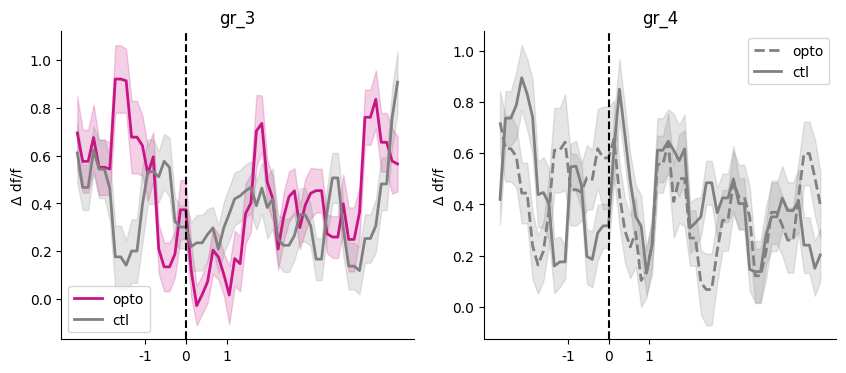

In [10]:
fig,axes = plt.subplots(1,2,figsize=(10,4))

grating = 'gr_3'
viz.plot_shaded_error(axes[0],range(60), np.vstack(data_red[ani]['activity'][grating][:,opto_idx]), color='mediumvioletred', label='opto', alpha=0.2,title=grating)
viz.plot_shaded_error(axes[0],range(60), np.vstack(data_red[ani]['activity'][grating][:,non_opto_idx]), color='grey', label='ctl', alpha=0.2,style=None)
axes[0].axvline(20, linestyle='--', color='k')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].set_ylabel('Δ df/f')
axes[0].set_xticks([12.5, 20, 27.5])
axes[0].set_xticklabels(['-1', '0', '1'])

grating = 'gr_4'
viz.plot_shaded_error(axes[1],range(60), np.vstack(data_red[ani]['activity'][grating][:,opto_idx]), color='grey', label='opto', alpha=0.2,title=grating,style='dash')
viz.plot_shaded_error(axes[1],range(60), np.vstack(data_red[ani]['activity'][grating][:,non_opto_idx]), color='grey', label='ctl', alpha=0.2,style=None)
axes[1].axvline(20, linestyle='--', color='k')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].set_ylabel('Δ df/f')
axes[1].set_xticks([12.5, 20, 27.5])
axes[1].set_xticklabels(['-1', '0', '1'])

(<Figure size 600x800 with 2 Axes>,
 <Axes: title={'center': 'gr_3'}, ylabel='#'>)

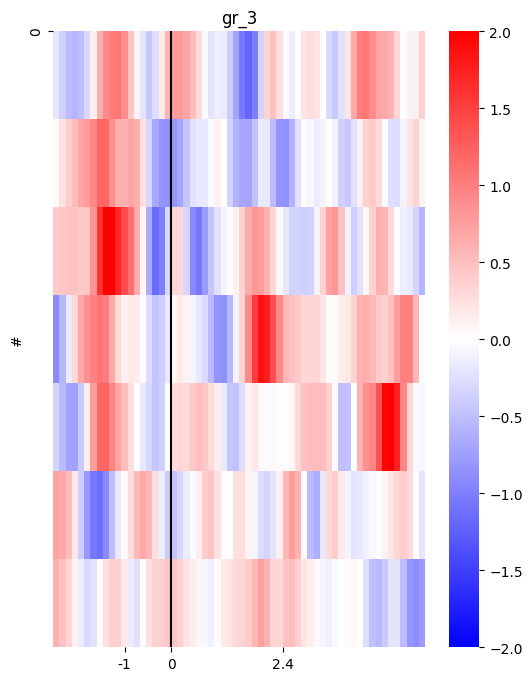

In [335]:
# add smoothing to the function plot_quick_heatmap
grating = 'gr_3'
viz.plot_quick_heatmap(data_red, ani, grating, opto_idx,
                       sort_frames=slice(23,33),
                       vmin=-2, vmax=2, figsize=(6,8),
                       difference=True, diff_trials=non_opto_idx,
                       smooth_sigma=1)

In [ ]:
# plot pupil
gr = 'gr_1'
fig,axes = plt.subplots(1,1,figsize=(5,4))
pupil = data[ani]['pupil_rel'][gr]
plt.plot(np.nanmean(data[ani]['pupil_rel'][gr],axis=0))